In [1]:
# Numpy für bessere Berechnungen
import numpy as np

%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib import colormaps

# Zum Auslesen von Dateien und ähnlichem
from pathlib import Path

import re

# Grafiken in EU-Größen ausgeben
def figsize_cm(width_cm, height_cm):
    return (2*width_cm / 2.54, 2*height_cm / 2.54)
def comma_to_float(valstr):
    return float(valstr.replace(',','.'))

In [2]:
currentversuch = "251"
base = Path.cwd()                   
Messwerte_path = Path(base.parent.parent.parent/"Messwerte"/currentversuch)      # initializing paths
Ausgabe_path = Path(base/currentversuch/"Diagramme")
print(Messwerte_path)
print(Ausgabe_path)


c:\Users\samue\OneDrive\Dokumente\PAP\Messwerte\251
c:\Users\samue\OneDrive\Dokumente\PAP\tex_files\Auswertungen_2.2\Code\251\Diagramme


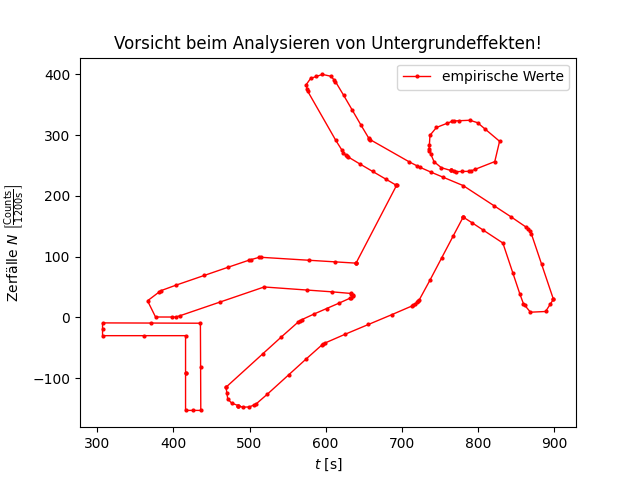

In [26]:
# data="""

# """

data=data1+data2+data3


data_blocks = [b.strip() for b in data.split('\n\n') if b.strip()]

pattern = r'([MLCZHV])\s*([\d\s.,-]+)?'      # ([]) ist Gruppe, speichert in Gruppe1 den Buchstaben [M oder L oder C] ab     \s* beliebig viele Leerzeichen  ()Gruppe zwei

plt.close('all')

for i, block in enumerate(data_blocks):    
    x=[]
    y=[]
    for command, values in re.findall(pattern, block):
        # Alle Zahlen im Block extrahieren und in Floats umwandeln
        nums = [float(n) for n in re.findall(r'[-+]?\d*\.?\d+', values.replace(',', ' '))] #[-+]?: negative Zahlen       \d*: beliebig viele Ziffern      \.?: optionaler Dezimalpunkt    \d+: Sucht nach mindestens einer Ziffer nach dem Punkt und wird von leerzeichen gestoppt

        # elif command == 'C' or command =='c':
        #     # Ein C-Befehl hat 6 Zahlen (x1, y1, x2, y2, x3, y3)
        #     # Wir wollen nur das letzte Paar (Index 4 und 5)
        #     x.append(nums[-2])
        #     y.append(nums[-1])

        if command == 'M' or command == 'L':
            if len(nums) >= 2:
                last_x, last_y = nums[0], nums[1]
                x.append(last_x)
                y.append(last_y)

        elif command == 'C':
        # Wir gehen in 6er-Schritten durch die Zahlen (i = 0, 6, 12...)
            for j in range(0, len(nums), 2):
            # Wir prüfen, ob wir genug Zahlen für ein komplettes Segment haben
                # Der echte Knoten ist immer das letzte Paar einer 6er-Gruppe
                    x.append(nums[j])
                    y.append(nums[j+1])
            
            # for j in range(0, len(nums), 6):
            # # Wir prüfen, ob wir genug Zahlen für ein komplettes Segment haben
            #     if j + 5 < len(nums):
            #     # Der echte Knoten ist immer das letzte Paar einer 6er-Gruppe
            #         x.append(nums[j+4])
            #         y.append(nums[j+5])
        elif command == 'H':
            # Nur X ändert sich, Y bleibt gleich
            if len(nums) >= 1:
                last_x = nums[0]    
                x.append(last_x)
                y.append(last_y)

        elif command == 'V':
            # Nur Y ändert sich, X bleibt gleich
            if len(nums) >= 1:
                last_y = nums[0]
                x.append(last_x)
                y.append(last_y)

        elif command == 'Z':
            if x:
                x.append(x[0])
                y.append(y[0])
                last_x, last_y = x[0], y[0]

    x=np.array(x)
    y=830-np.array(y)
    if i == 0:
        labeltext=r'empirische Werte'
    elif i==2:
        labeltext=None        # Nur beim nullten Durchgang das Label setzen
    else: labeltext=None
        
    if i>1:
        plt.plot(x, y,color=f"red",marker='.',markersize=4,linestyle='-',linewidth=1, label=labeltext)#color=f"C{1}"
    else:
        plt.plot(x, y,color='red',marker='.',markersize=4,linewidth=1, label=labeltext)#color=f"C{1}" Frabe orange #f9aa00

plt.title(r'Vorsicht beim Analysieren von Untergrundeffekten!')
plt.xlabel(r'$t$ [s]')
plt.ylabel(r'Zerfälle $N$ $\left[\frac{\mathrm{Counts}}{1200\mathrm{s}}\right]$')
plt.legend()

plt.show()
plt.savefig(Ausgabe_path/"memefallend.png",format="png")


# Dangerous Inkscape

# Falling man

In [ ]:
data1="""
# M 416 921.5
# L 416 860
# L 361.5 860
# L 307 860
# L 307 849.49
# L 307 838.99
# L 371.25 839.24
# L 435.5 839.5
# L 435.76 911.25
# L 436.01 983
# L 426.01 983
# L 416 983
# M 416 921.5

"""
data2="""
M 485 974.98
C 476.49 971.01 471.39 964.09 470.32 955.06
C 469.11 944.83 469.08 944.88 517.45 889.81
C 541.88 862 563.87 837.61 566.31 835.61
C 568.75 833.6 584.42 824.51 601.12 815.39
C 617.83 806.28 632.29 798.12 633.25 797.26
C 635.34 795.39 635.52 792.67 633.65 791.12
C 632.87 790.48 608.39 787.86 575.75 784.93
L 519.19 779.86
L 461.42 804.6
C 408.88 827.1 403.15 829.33 398.08 829.32
C 376.59 829.28 366.09 802.58 381.73 787.74
C 383.64 785.92 403.85 776.69 440.57 760.87
C 471.33 747.61 498.98 735.89 502 734.82
C 512.93 730.95 514.47 730.97 578.5 735.92
C 612.05 738.51 639.53 740.6 639.57 740.57
C 640.05 740.14 693.03 612.71 692.81 612.52
C 692.64 612.38 678.55 602.04 661.5 589.55
C 644.45 577.05 629.22 565.63 627.65 564.16
C 626.09 562.7 623.34 558.58 621.54 555
C 613.39 538.77 576.16 457.19 575.71 454.57
C 574.39 446.92 580.25 436.58 587.72 433.38
C 595.65 429.98 607.05 433.09 611.52 439.87
C 612.84 441.87 623.4 463.95 635 488.95
C 646.6 513.95 656.62 535.04 657.26 535.82
C 658.71 537.56 709.84 574.02 719.5 580.19
C 723.35 582.65 738.65 591.03 753.5 598.82
L 780.5 612.97
L 821.21 646.26
C 843.6 664.58 863.54 681.64 865.52 684.19
C 868.89 688.51 870.11 692.46 883.6 742.66
C 899.09 800.27 899.05 800.06 894.95 808.09
C 888.77 820.21 868.91 821.37 861.42 810.05
C 859.7 807.46 855.02 791.54 845.81 756.92
L 832.65 707.5
L 806.75 686.15
C 792.51 674.41 780.71 664.96 780.52 665.15
C 780.34 665.34 767.57 695.59 752.14 732.37
C 736.72 769.15 722.9 800.98 721.44 803.09
C 719.97 805.21 717.16 808.16 715.2 809.66
C 713.23 811.16 686.62 825.54 656.06 841.61
C 625.5 857.68 598.83 872.24 596.78 873.95
C 594.73 875.66 574.35 898.36 551.48 924.38
C 523.23 956.51 508.6 972.42 505.84 973.97
C 499.96 977.27 490.86 977.72 485 974.98
M 485 974.98
"""
data3="""
M 764.27 588.1
C 751.75 583.46 742.28 573.67 737.96 560.92
C 736.22 555.76 735.87 552.83 736.19 545.98
C 736.93 530.25 745.43 517.36 759.72 510.29
C 765.99 507.2 768.39 506.57 775.4 506.2
C 789.36 505.47 799.42 509.47 808.93 519.52
C 828.35 540.06 822.03 573.5 796.34 586.15
C 790.29 589.13 788.61 589.49 779.56 589.75
C 771.56 589.98 768.43 589.64 764.27 588.1
M 764.27 588.1
"""

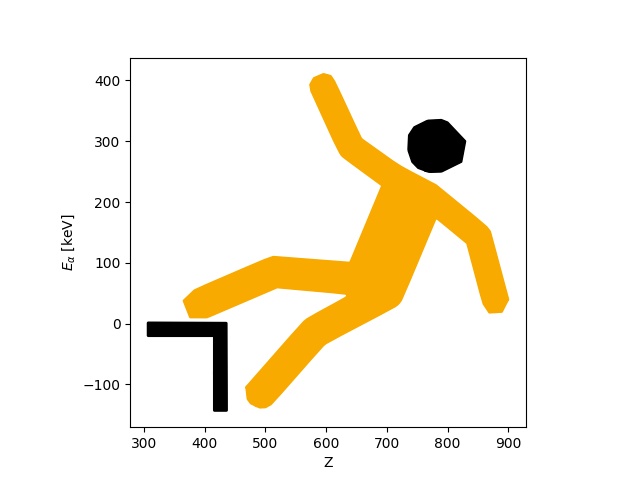

In [5]:
# data="""

# """
data=data1+data2+data3

data_blocks = [b.strip() for b in data.split('\n\n') if b.strip()]

pattern = r'([MLCZHV])\s*([\d\s.,-]+)?'      # ([]) ist Gruppe, speichert in Gruppe1 den Buchstaben [M oder L oder C] ab     \s* beliebig viele Leerzeichen  ()Gruppe zwei

plt.close('all')
for i, block in enumerate(data_blocks):    
    x=[]
    y=[]
    for command, values in re.findall(pattern, block):
        # Alle Zahlen im Block extrahieren und in Floats umwandeln
        nums = [float(n) for n in re.findall(r'[-+]?\d*\.?\d+', values.replace(',', ' '))] #[-+]?: negative Zahlen       \d*: beliebig viele Ziffern      \.?: optionaler Dezimalpunkt    \d+: Sucht nach mindestens einer Ziffer nach dem Punkt und wird von leerzeichen gestoppt

        # elif command == 'C' or command =='c':
        #     # Ein C-Befehl hat 6 Zahlen (x1, y1, x2, y2, x3, y3)
        #     # Wir wollen nur das letzte Paar (Index 4 und 5)
        #     x.append(nums[-2])
        #     y.append(nums[-1])

        if command == 'M' or command == 'L':
            if len(nums) >= 2:
                last_x, last_y = nums[0], nums[1]
                x.append(last_x)
                y.append(last_y)

        elif command == 'C':
                for j in range(0,len(nums),2):
                    last_x, last_y = nums[j], nums[j+1]
                    x.append(last_x)
                    y.append(last_y)
        # # Wir gehen in 6er-Schritten durch die Zahlen (i = 0, 6, 12...)
        #     for j in range(0, len(nums), 6):
        #     # Wir prüfen, ob wir genug Zahlen für ein komplettes Segment haben
        #         if j + 5 < len(nums):
        #         # Der echte Knoten ist immer das letzte Paar einer 6er-Gruppe
        #             x.append(nums[j+4])
        #             y.append(nums[j+5])
            
        elif command == 'H':
            # Nur X ändert sich, Y bleibt gleich
            if len(nums) >= 1:
                last_x = nums[0]    
                x.append(last_x)
                y.append(last_y)

        elif command == 'V':
            # Nur Y ändert sich, X bleibt gleich
            if len(nums) >= 1:
                last_y = nums[0]
                x.append(last_x)
                y.append(last_y)

        elif command == 'Z':
            if x:
                x.append(x[0])
                y.append(y[0])
                last_x, last_y = x[0], y[0]

    x=np.array(x)
    y=840-np.array(y)
  
    if i==0 or i>1:
        if i == 0:
            labeltext=r'Betriebsverstärkung'
        else: labeltext=None
        plt.plot(x, y,color=f"black",linewidth=2, label=labeltext)#color=f"C{1}"
        plt.fill(x, y,color=f"black",)#color=f"C{1}"
    else:
        if i==1:
            labeltext=r'Leerlaufverstärkung'        # Nur beim nullten Durchgang das Label setzen
        plt.plot(x, y,color='#f9aa00',linewidth=2, label=labeltext)#color=f"C{1}"
        plt.fill(x, y, color='#f9aa00')#color=f"C{1}"

plt.xlabel(r'Z')
plt.ylabel(r'$E_\alpha$ [keV]')
# plt.legend()s
plt.gca().set_aspect('equal')
plt.show()
plt.savefig(Ausgabe_path/"Memefilled.png",format="png")
